# Fire and Engineering Risk Profile — Exploratory & Risk Analysis

**Source file:** `icealion-data-analytics_analytics_gen_sq_fire_eng_risk_profile_ug.xlsx`
**Scope:** Fire and Engineering treaty business, Uganda
**Records:** 11,303 policies | **Fields:** 89 columns (policy, sum insured, premium, claims, reinsurance structure, risk classification)

This notebook profiles the Fire & Engineering book from a **risk** perspective: data
quality first, then portfolio composition, loss-ratio drivers, risk concentration, and
the largest individual losses in the book. Every chart and table below is generated
live from the underlying data — re-run any cell to refresh it.

## 1. Setup & Data Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


# --- Colour palette used throughout ---
NAVY, BLUE, GOLD, LIGHT_BLUE, PALE, GREY = "#0B2E5C", "#1F4E96", "#C9A227", "#8FAEDD", "#D9E4F5", "#6B7A99"
plt.rcParams.update({
    "font.size": 10, "axes.edgecolor": "#CCCCCC", "axes.grid": True,
    "grid.color": "#E5E5E5", "grid.linewidth": 0.6, "axes.axisbelow": True,
})

df = pd.read_excel("data.xlsx", sheet_name="Sheet1")
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print(f"Underwriting years covered: {int(df['pol_uw_year'].min())}–{int(df['pol_uw_year'].max())}")

c:\Users\matukunda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Rows: 11,303   Columns: 89
Underwriting years covered: 2000–2026


In [ ]:
pip install seaborn


The dataset combines four things for every policy: **sum insured** (`si_*`), **premium**
(`prm_*`), **claims** (`clm_*`), and the **reinsurance placement structure** (`ri_*` —
surplus lines, quota share, facultative, etc.). `treaty_group_name` splits the book into
**Fire** and **Engineering**.

## 2. Data Quality Assessment

In [2]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print("Columns with missing data (top 10 of {}):".format(len(missing)))
print(missing.head(10).round(1).to_string())

Columns with missing data (top 10 of 13):
ri_risk_class_name            95.1
ri_risk_class_code            95.1
ri_construction_class_code    47.8
ri_construction_class_name    47.8
clt_sector                    47.5
ri_postal_code                33.5
si_item_count                 30.7
lr_gross                       2.3
lr_net                         2.0
ri_placement_count             0.1


**Read:** `ri_risk_class_name` (95% missing) and `clt_sector` (47% missing) are too sparse
to analyse reliably on their own — treat any risk-class or sector finding below as
*indicative*, based on the ~5–50% of records that do carry a value, not the full book.
`ri_construction_class_name` is missing for 48% of records, mostly because the field is
only captured for larger/inspected risks.

In [3]:
dup_pol = df.duplicated(subset=["pol_no"]).sum()
neg_prem = (df["prm_gross_written"] < 0).sum()
zero_si = (df["si_gross_sum_insured"] <= 0).sum()

print(f"Duplicate policy numbers:      {dup_pol}")
print(f"Negative gross written premium: {neg_prem} records (likely mid-term cancellations/refunds)")
print(f"Zero or missing sum insured:    {zero_si} records ({zero_si/len(df)*100:.1f}% of book)")

Duplicate policy numbers:      198
Negative gross written premium: 31 records (likely mid-term cancellations/refunds)
Zero or missing sum insured:    3642 records (32.2% of book)


### ⚠️ Critical data-quality flag: claims exceeding sum insured

For a normal indemnity fire/engineering policy, incurred claims should not exceed the sum
insured. **72 policies break this rule** — some by orders of magnitude. This is worth
investigating before the sum-insured field is used for pricing, PML, or accumulation
purposes, since it suggests either stale/un-updated SI values or a claims-to-policy
linkage issue.

In [4]:
mask = (df["si_gross_sum_insured"] > 0) & (df["clm_gross_incurred"] > df["si_gross_sum_insured"])
anomaly = df[mask].copy()
anomaly["ratio_x"] = (anomaly["clm_gross_incurred"] / anomaly["si_gross_sum_insured"]).round(0)

print(f"Policies where incurred claims exceed sum insured: {mask.sum()} ({mask.sum()/len(df)*100:.2f}% of book)")
print()
cols = ["insured_name", "si_gross_sum_insured", "clm_gross_incurred", "ratio_x", "pol_uw_year", "treaty_group_name"]
print(anomaly.sort_values("ratio_x", ascending=False)[cols].head(8).to_string(index=False))

Policies where incurred claims exceed sum insured: 72 (0.64% of book)

                                    insured_name  si_gross_sum_insured  clm_gross_incurred  ratio_x  pol_uw_year treaty_group_name
    NILUS GROUP LIMITED/UGANDA TOBACCO SERVICES.             1072791.0        8.991081e+09   8381.0         2026              Fire
                              PCP UGANDA LIMITED               11800.0        1.750040e+07   1483.0         2014       Engineering
       ROVIS INVESTMENTS LTD/AFRICAN RIVERS FUND              150000.0        1.162813e+08    775.0         2018       Engineering
              IGAD REGIONAL HIV$AIDS PARTNERSHIP               81150.0        5.811359e+07    716.0         2018       Engineering
              AIRCOM SYSTEMS LIMITED / EXIM BANK              300000.0        2.133242e+08    711.0         2025              Fire
GUARDIAN REINSURANCE/ LAGAN DOTT NAMANVE LIMITED             3608450.0        2.270646e+09    629.0         2020       Engineering
            

The most extreme case — **NILUS GROUP LIMITED / UGANDA TOBACCO SERVICES** — shows
incurred claims of UGX 8.99B against a sum insured of just UGX 1.07M, a **~8,381×**
ratio. That is not a plausible fire loss outcome and almost certainly reflects a data
issue (wrong currency/units, or a claim linked to the wrong policy) rather than a real
underwriting result.

## 3. Portfolio Overview

In [5]:
overview = df.groupby("treaty_group_name").agg(
    policies=("pol_no", "count"),
    gwp=("prm_gross_written", "sum"),
    incurred=("clm_gross_incurred", "sum"),
)
overview["loss_ratio"] = overview["incurred"] / overview["gwp"]
print(overview.round(3).to_string())

total_gwp = df["prm_gross_written"].sum()
total_net = df["prm_net_written"].sum()
total_inc_g = df["clm_gross_incurred"].sum()
total_inc_n = df["clm_net_incurred"].sum()
print()
print(f"Portfolio Gross Written Premium: UGX {total_gwp:,.0f}")
print(f"Portfolio Net Written Premium:   UGX {total_net:,.0f}  ({total_net/total_gwp*100:.1f}% of gross — most risk is ceded out)")
print(f"Portfolio Gross Loss Ratio:      {total_inc_g/total_gwp*100:.1f}%")
print(f"Portfolio Net Loss Ratio:        {total_inc_n/total_net*100:.1f}%")

                   policies           gwp      incurred  loss_ratio
treaty_group_name                                                  
Engineering            1183  7.000127e+10  3.243257e+10       0.463
Fire                  10120  1.106594e+11  3.066504e+10       0.277

Portfolio Gross Written Premium: UGX 180,660,701,724
Portfolio Net Written Premium:   UGX 43,709,156,569  (24.2% of gross — most risk is ceded out)
Portfolio Gross Loss Ratio:      34.9%
Portfolio Net Loss Ratio:        6.1%


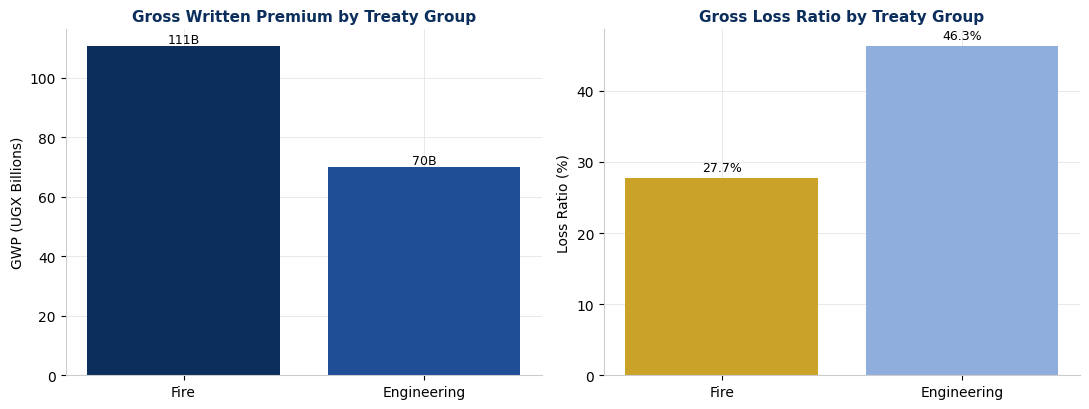

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ov = overview.sort_values("gwp", ascending=False)
axes[0].bar(ov.index, ov["gwp"]/1e9, color=[NAVY, BLUE])
axes[0].set_title("Gross Written Premium by Treaty Group", fontsize=11, color=NAVY, fontweight="bold")
axes[0].set_ylabel("GWP (UGX Billions)")
for i, v in enumerate(ov["gwp"]/1e9):
    axes[0].text(i, v + 1, f"{v:,.0f}B", ha="center", fontsize=9)

axes[1].bar(ov.index, ov["loss_ratio"]*100, color=[GOLD, LIGHT_BLUE])
axes[1].set_title("Gross Loss Ratio by Treaty Group", fontsize=11, color=NAVY, fontweight="bold")
axes[1].set_ylabel("Loss Ratio (%)")
for i, v in enumerate(ov["loss_ratio"]*100):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

for ax in axes:
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Read:** Engineering is the smaller book by premium (28% of GWP) but runs a
meaningfully **higher loss ratio (46.3% vs 27.7% for Fire)** — consistent with
engineering risks (construction, machinery breakdown, erection all-risks) being more
loss-prone per shilling of premium than standard fire risk.

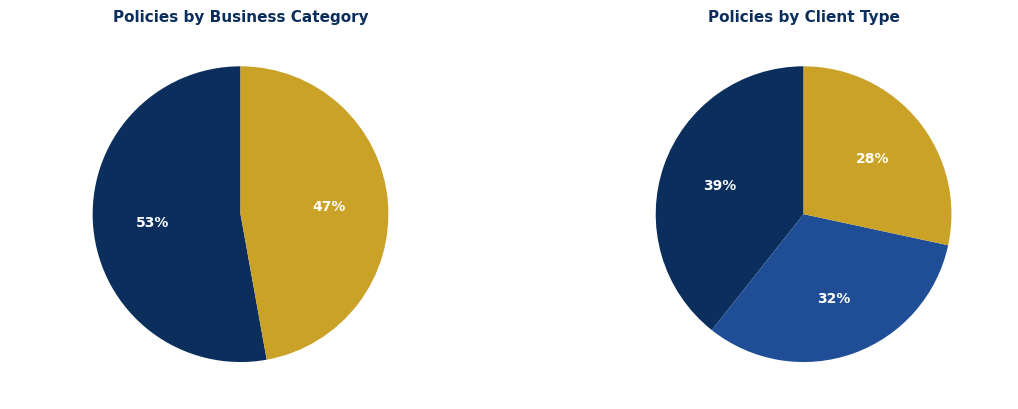

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

bc = df["pol_business_category"].value_counts()
axes[0].pie(bc.values, labels=["Personal" if l=="PERS" else "Commercial" for l in bc.index],
            colors=[NAVY, GOLD], autopct="%1.0f%%", startangle=90,
            textprops={"fontsize": 10, "color": "white", "fontweight": "bold"})
axes[0].set_title("Policies by Business Category", fontsize=11, color=NAVY, fontweight="bold")

ct = df["clt_type"].value_counts()
axes[1].pie(ct.values, labels=ct.index, colors=[NAVY, BLUE, GOLD], autopct="%1.0f%%", startangle=90,
            textprops={"fontsize": 10, "color": "white", "fontweight": "bold"})
axes[1].set_title("Policies by Client Type", fontsize=11, color=NAVY, fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Portfolio & Loss Ratio Trend (2012–2026)

Years before 2012 have too few policies to be meaningful (under 100/year) and are
excluded from the trend view below.

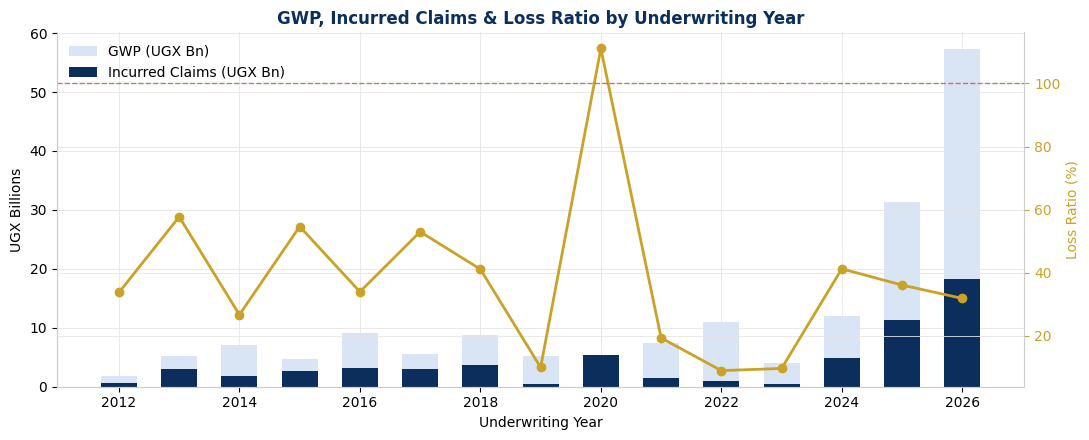

In [8]:
trend = df[df["pol_uw_year"] >= 2012].groupby("pol_uw_year").agg(
    gwp=("prm_gross_written", "sum"),
    incurred=("clm_gross_incurred", "sum"),
)
trend["loss_ratio"] = trend["incurred"] / trend["gwp"]

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(trend.index, trend["gwp"]/1e9, color=PALE, label="GWP (UGX Bn)", width=0.6)
ax1.bar(trend.index, trend["incurred"]/1e9, color=NAVY, label="Incurred Claims (UGX Bn)", width=0.6)
ax1.set_ylabel("UGX Billions")
ax1.set_xlabel("Underwriting Year")
ax1.legend(loc="upper left", frameon=False)
ax1.spines[["top","right"]].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(trend.index, trend["loss_ratio"]*100, color=GOLD, marker="o", linewidth=2, label="Loss Ratio (%)")
ax2.set_ylabel("Loss Ratio (%)", color=GOLD)
ax2.tick_params(axis="y", colors=GOLD)
ax2.spines[["top"]].set_visible(False)
ax2.axhline(100, color="#B22222", linestyle="--", linewidth=1, alpha=0.6)

plt.title("GWP, Incurred Claims & Loss Ratio by Underwriting Year", fontsize=12, color=NAVY, fontweight="bold")
plt.tight_layout()
plt.show()

## 4A. Fire vs Engineering: Annual Claim Frequency and Loss Ratio

Claim frequency is measured at policy level because the source contains policy-level incurred claims rather than individual claim records: **frequency = policies with gross incurred claims > 0 / policies**. The tables below separate Fire and Engineering for every underwriting year from 2012 onward. Loss ratio remains **gross incurred claims / gross written premium**. `Claim frequency` answers how often a policy has a claim; `loss ratio` also reflects claim severity and premium adequacy.

In [ ]:
annual = df[df["pol_uw_year"] >= 2012].copy()
annual["claim_flag"] = annual["clm_gross_incurred"].fillna(0) > 0

annual_group = (annual.groupby(["treaty_group_name", "pol_uw_year"])
                .agg(policies=("pol_no", "count"),
                     claim_policies=("claim_flag", "sum"),
                     gwp=("prm_gross_written", "sum"),
                     incurred=("clm_gross_incurred", "sum"))
                .reset_index())
annual_group["claim_frequency"] = annual_group["claim_policies"] / annual_group["policies"]
annual_group["loss_ratio"] = annual_group["incurred"] / annual_group["gwp"].replace(0, np.nan)
annual_group["avg_claim_per_claim_policy"] = annual_group["incurred"] / annual_group["claim_policies"].replace(0, np.nan)

for group in ["Fire", "Engineering"]:
    view = annual_group[annual_group["treaty_group_name"] == group].copy()
    view = view.set_index("pol_uw_year")
    print(f"\n{group.upper()} - ANNUAL EXPERIENCE")
    print(view[["policies", "claim_policies", "claim_frequency", "gwp", "incurred", "loss_ratio", "avg_claim_per_claim_policy"]]
          .rename(columns={"gwp": "gwp_ugx", "incurred": "incurred_ugx"})
          .round({"claim_frequency": 4, "loss_ratio": 4, "avg_claim_per_claim_policy": 0})
          .to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for row, group in enumerate(["Fire", "Engineering"]):
    view = annual_group[annual_group["treaty_group_name"] == group]
    axes[row, 0].plot(view["pol_uw_year"], view["claim_frequency"] * 100,
                      color=BLUE, marker="o", linewidth=2)
    axes[row, 0].set_title(f"{group}: Claim Frequency", color=NAVY, fontweight="bold")
    axes[row, 0].set_ylabel("Claiming policies (%)")
    axes[row, 0].set_ylim(bottom=0)
    axes[row, 1].plot(view["pol_uw_year"], view["loss_ratio"] * 100,
                      color=GOLD, marker="o", linewidth=2)
    axes[row, 1].set_title(f"{group}: Gross Loss Ratio", color=NAVY, fontweight="bold")
    axes[row, 1].set_ylabel("Loss ratio (%)")
    axes[row, 1].axhline(100, color="#B22222", linestyle="--", linewidth=1, alpha=0.6)
    axes[row, 1].set_ylim(bottom=0)

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Underwriting Year")
    ax.grid(axis="x", visible=False)
plt.suptitle("Annual Claim Frequency and Loss Ratio by Treaty Group", fontsize=13, color=NAVY, fontweight="bold")
plt.tight_layout()
plt.show()

**Read:** 2020 stands out — the only year the gross loss ratio **exceeded 100%** (111%),
driven by a small number of large engineering/fire losses rather than a broad
deterioration. The book has grown sharply since 2024 (GWP roughly tripling by 2026),
which makes 2025–2026 loss-ratio trends important to watch closely as that growth
matures and claims develop.

## 5. Risk Concentration

In [9]:
top_insureds = (df.groupby("insured_name")["si_gross_sum_insured"].sum()
                 .sort_values(ascending=False).head(10))
total_si = df["si_gross_sum_insured"].sum()
top10_share = top_insureds.sum() / total_si * 100
print(f"Top 10 insureds account for {top10_share:.1f}% of total gross sum insured in the book.")

Top 10 insureds account for 24.7% of total gross sum insured in the book.


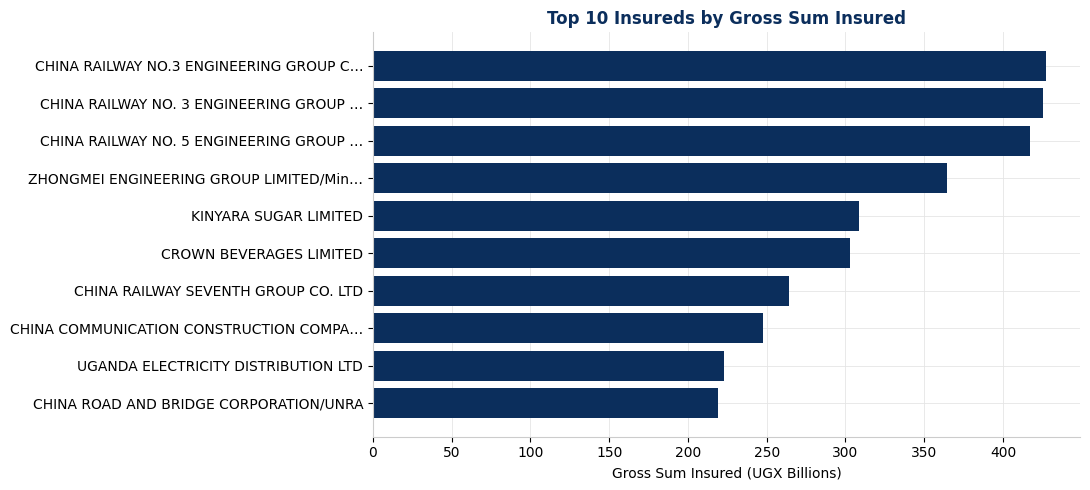

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
labels = [n[:38] + ("…" if len(n) > 38 else "") for n in top_insureds.index[::-1]]
ax.barh(labels, top_insureds.values[::-1]/1e9, color=NAVY)
ax.set_xlabel("Gross Sum Insured (UGX Billions)")
ax.set_title("Top 10 Insureds by Gross Sum Insured", fontsize=12, color=NAVY, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Read:** Large civil-works contractors (several China Railway / China Communications
Construction entities on Uganda National Roads Authority projects) dominate the top of
the book alongside a handful of major industrial risks (Kinyara Sugar, Crown Beverages).
This is typical for a treaty book with sizeable infrastructure exposure, but it means a
single major loss event at one of these insureds would have an outsized impact on the
year's result — worth monitoring via PML/EML rather than sum insured alone.

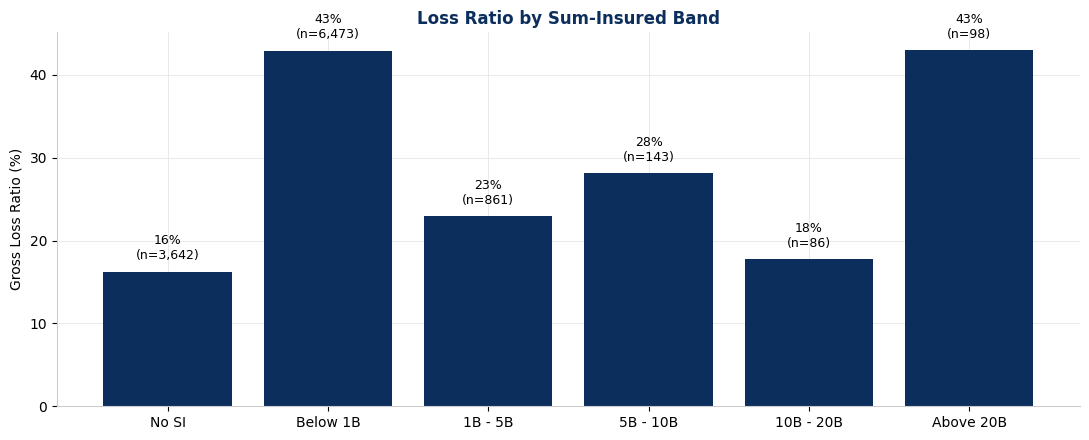

In [11]:
band_order = ["No SI", "Below 1B", "1B - 5B", "5B - 10B", "10B - 20B", "Above 20B"]
band = df.groupby("si_band").agg(policies=("pol_no","count"), gwp=("prm_gross_written","sum"),
                                   incurred=("clm_gross_incurred","sum"))
band["loss_ratio"] = band["incurred"] / band["gwp"]
band = band.reindex(band_order)

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(band.index, band["loss_ratio"]*100, color=NAVY)
for i, (p, lr) in enumerate(zip(band["policies"], band["loss_ratio"]*100)):
    ax.text(i, lr + 1.5, f"{lr:.0f}%\n(n={p:,})", ha="center", fontsize=9)
ax.set_ylabel("Gross Loss Ratio (%)")
ax.set_title("Loss Ratio by Sum-Insured Band", fontsize=12, color=NAVY, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Read:** Loss ratio is **not** simply "bigger risk = worse result" here. The two worst-
performing bands are the two extremes — **"Below 1B"** (small risks, 42.9% LR) and
**"Above 20B"** (mega risks, 43.0% LR) — while the UGX 1B–20B mid-market bands perform
noticeably better (17–28% LR). Small risks likely suffer from thinner premium adequacy
per policy; mega risks are exposed to occasional severe single losses.

## 6. Loss Ratio Drivers

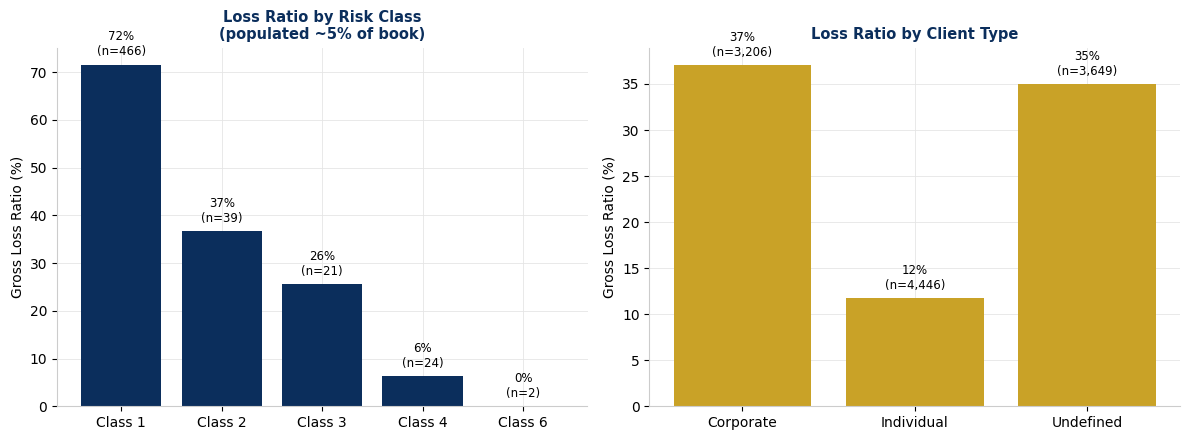

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rc = df.groupby("ri_risk_class_name").agg(gwp=("prm_gross_written","sum"), incurred=("clm_gross_incurred","sum"),
                                            n=("pol_no","count"))
rc["lr"] = rc["incurred"]/rc["gwp"]
rc = rc.sort_index()
axes[0].bar(rc.index, rc["lr"]*100, color=NAVY)
for i,(lr,n) in enumerate(zip(rc["lr"]*100, rc["n"])):
    axes[0].text(i, lr+2, f"{lr:.0f}%\n(n={n})", ha="center", fontsize=8.5)
axes[0].set_title("Loss Ratio by Risk Class\n(populated ~5% of book)", fontsize=10.5, color=NAVY, fontweight="bold")
axes[0].set_ylabel("Gross Loss Ratio (%)")
axes[0].spines[["top","right"]].set_visible(False)

ct = df.groupby("clt_type").agg(gwp=("prm_gross_written","sum"), incurred=("clm_gross_incurred","sum"), n=("pol_no","count"))
ct["lr"] = ct["incurred"]/ct["gwp"]
axes[1].bar(ct.index, ct["lr"]*100, color=GOLD)
for i,(lr,n) in enumerate(zip(ct["lr"]*100, ct["n"])):
    axes[1].text(i, lr+1, f"{lr:.0f}%\n(n={n:,})", ha="center", fontsize=8.5)
axes[1].set_title("Loss Ratio by Client Type", fontsize=10.5, color=NAVY, fontweight="bold")
axes[1].set_ylabel("Gross Loss Ratio (%)")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Read (with the earlier caveat that risk class is only populated for ~5% of the book):**
Among policies that do carry a risk classification, **Class 1** risks run a striking
**71.5% loss ratio** — far above Classes 2–4. Separately, and on much fuller data,
**Corporate risks (37.1% LR) run three times worse than Individual risks (11.7% LR)** —
the retail/individual side of the Fire book is comfortably profitable, while corporate
risk is where the underwriting result is being made or lost.

In [13]:
branch = df.groupby("pol_branch_name").agg(gwp=("prm_gross_written","sum"), incurred=("clm_gross_incurred","sum"),
                                              n=("pol_no","count"))
branch["lr"] = branch["incurred"]/branch["gwp"]
branch = branch[branch["gwp"] > 1e9].sort_values("gwp", ascending=False)  # material branches only
print("Branches with over UGX 1B in GWP:")
print(branch[["n","gwp","lr"]].rename(columns={"n":"policies","gwp":"gwp_ugx","lr":"loss_ratio"}).round(3).to_string())

Branches with over UGX 1B in GWP:
                 policies       gwp_ugx  loss_ratio
pol_branch_name                                    
Kampala              7300  1.187642e+11       0.253
Hanington House      1702  2.507090e+10       0.426
RUMEE                 904  1.631498e+10       0.310
Facultative           408  1.512761e+10       0.928
ZEBRA                 368  2.349212e+09       0.107
Mbarara               339  1.215337e+09       0.029


**Read:** The **Facultative** channel stands out — UGX 15.1B of GWP running a **92.7%**
loss ratio, by far the worst of any material branch/channel. **Kampala**, the largest
branch by volume (UGX 118.8B GWP), runs a healthy 25.3% — the book's core retail branch
network is performing well; concentration risk sits in facultative placements and a
handful of very large individual risks, not in the branch network broadly.

## 7. Largest Individual Losses

In [14]:
cols = ["insured_name","treaty_group_name","pol_uw_year","clm_gross_incurred","prm_gross_written","si_gross_sum_insured"]
top_losses = df.nlargest(10, "clm_gross_incurred")[cols].copy()
for c in ["clm_gross_incurred","prm_gross_written","si_gross_sum_insured"]:
    top_losses[c] = top_losses[c].map(lambda x: f"{x:,.0f}")
print(top_losses.to_string(index=False))

                                                                              insured_name treaty_group_name  pol_uw_year clm_gross_incurred prm_gross_written si_gross_sum_insured
                                              NILUS GROUP LIMITED/UGANDA TOBACCO SERVICES.              Fire         2026      8,991,080,880        16,305,798            1,072,791
                                                                     KINYARA SUGAR LIMITED              Fire         2025      2,950,502,318     6,369,092,417      243,966,843,474
                                                 ABYSSINIA IRON AND STEEL (UGANDA) LIMITED              Fire         2025      2,842,314,658       271,101,001       77,633,000,000
                                                                     KINYARA SUGAR LIMITED       Engineering         2025      2,684,479,831     3,457,142,333           30,315,532
PEARL ENGINEERING COMPANY LTD/ EARTH-TECH ENGINEERS LTD/ MINISTRY OF WATER AND ENVIRONMENT       Eng

**Read:** Excluding the NILUS/Uganda Tobacco Services data-anomaly noted earlier, the
largest genuine losses cluster around **Kinyara Sugar** (appears twice in the top ten —
worth a closer look at that account specifically), large **Engineering** infrastructure
risks tied to China Railway / road-authority contracts, and a few sizeable Fire losses
(Abyssinia Iron and Steel, Achwa Dam). Engineering risks dominate the largest-loss list
even though Fire is the bigger book by premium — consistent with the higher Engineering
loss ratio seen earlier.

## 8. Key Insights & Recommendations

**Data Quality**
1. **Fix before relying on Sum Insured for accumulation/PML work:** 72 policies show
   incurred claims exceeding sum insured, one by ~8,000×. This looks like a data
   linkage or currency/unit error, not genuine underwriting experience, and should be
   corrected at source.
2. `ri_risk_class_name` (95% missing) and `clt_sector` (47% missing) are too sparse to
   drive risk-class or sector-level decisions today — closing this gap at point of sale
   would materially improve future risk analysis.
3. 255 policies carry zero gross written premium and 31 carry negative premium —
   worth confirming these are legitimate cancellations/adjustments rather than data
   entry gaps.

**Portfolio & Risk**
4. **Engineering runs a materially worse loss ratio than Fire** (46.3% vs 27.7%) despite
   being the smaller book — a natural focus area for underwriting review.
5. **Risk is concentrated**: the top 10 insureds hold ~25% of total sum insured, largely
   major infrastructure contractors — a small number of large losses could swing the
   year's result.
6. **Facultative placements are the single worst-performing channel** (92.7% loss ratio
   on UGX 15.1B GWP) — disproportionate to its size and worth a dedicated review.
7. **Corporate risk drives the loss ratio; Individual risk is comfortably profitable**
   (37.1% vs 11.7% LR) — underwriting attention is best focused on the corporate book.
8. **2020 was the only year with a gross loss ratio above 100%** (111%), driven by a
   small number of large losses rather than a systemic deterioration — not, on this
   evidence, a trend to extrapolate forward on its own.
9. The book has grown sharply since 2024; **2025–2026 experience is still early** and
   worth monitoring closely as claims on this newer business develop.

*All figures are gross of reinsurance unless stated otherwise; net figures are
available in the same dataset (`*_net` columns) for a ceded-risk view.*